In [6]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('C:/Users/Евгений/Git/neural-network-vk-classification/data/raw/vk_posts1.csv')
df

,text,comments,likes,group_id
0,Такой мангал должен быть у каждого железнодоро...,10,341,766121
1,"Архангельская область, депо Сольвычегодск\n\nА...",0,15,766121
2,NaN,9,12,766121
3,NaN,3,97,766121
4,😎🖐,0,19,766121
...,...,...,...,...
3995,«Горэлектротранс» представил макет инновационн...,6,49,38545497
3996,"Ровно 8 лет назад учебная ""Машка"" ЛМ-68М на Бу...",9,95,38545497
3997,Возвращаем после перерыва нашу рубрику #день_в...,20,122,38545497
3998,Вспомним высокопольные троллейбусы\n\nНа фотог...,16,129,38545497


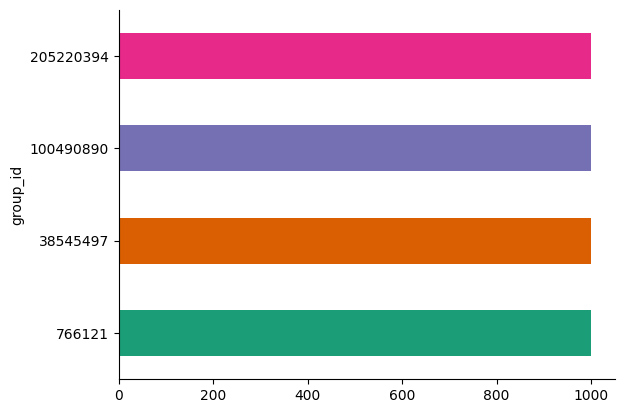

In [ ]:
df.groupby('group_id').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

c:\Users\Евгений\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Евгений\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


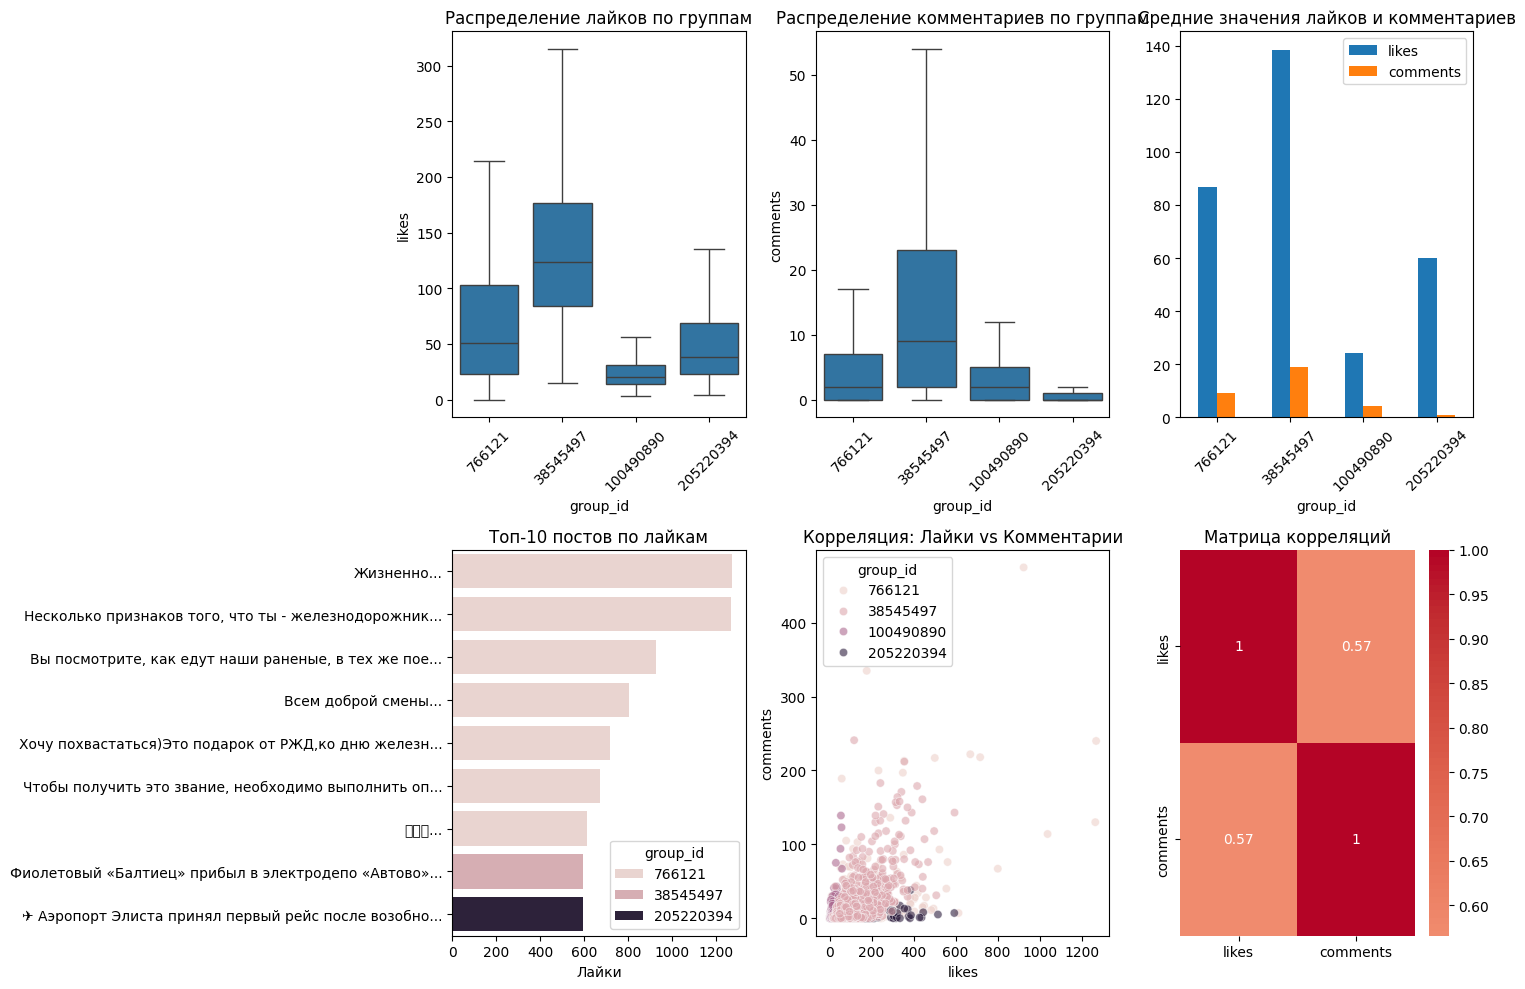

In [13]:
# 2.1 Статистика лайков и комментариев по группам
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='group_id', y='likes', showfliers=False)
plt.title('Распределение лайков по группам')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='group_id', y='comments', showfliers=False)
plt.title('Распределение комментариев по группам')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
# Средние значения
avg_metrics = df.groupby('group_id')[['likes', 'comments']].mean()
avg_metrics.plot(kind='bar', ax=plt.gca())
plt.title('Средние значения лайков и комментариев')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
# Топ постов по лайкам
top_likes = df.nlargest(10, 'likes')[['text', 'likes', 'group_id']].copy()
top_likes['text_short'] = top_likes['text'].str[:50] + '...'
sns.barplot(data=top_likes, x='likes', y='text_short', hue='group_id', dodge=False)
plt.title('Топ-10 постов по лайкам')
plt.xlabel('Лайки')
plt.ylabel('')

plt.subplot(2, 3, 5)
# Корреляция лайков и комментариев
sns.scatterplot(data=df, x='likes', y='comments', hue='group_id', alpha=0.6)
plt.title('Корреляция: Лайки vs Комментарии')

plt.subplot(2, 3, 6)
# Heatmap корреляций
correlation_matrix = df[['likes', 'comments']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций')

plt.tight_layout()
plt.show()

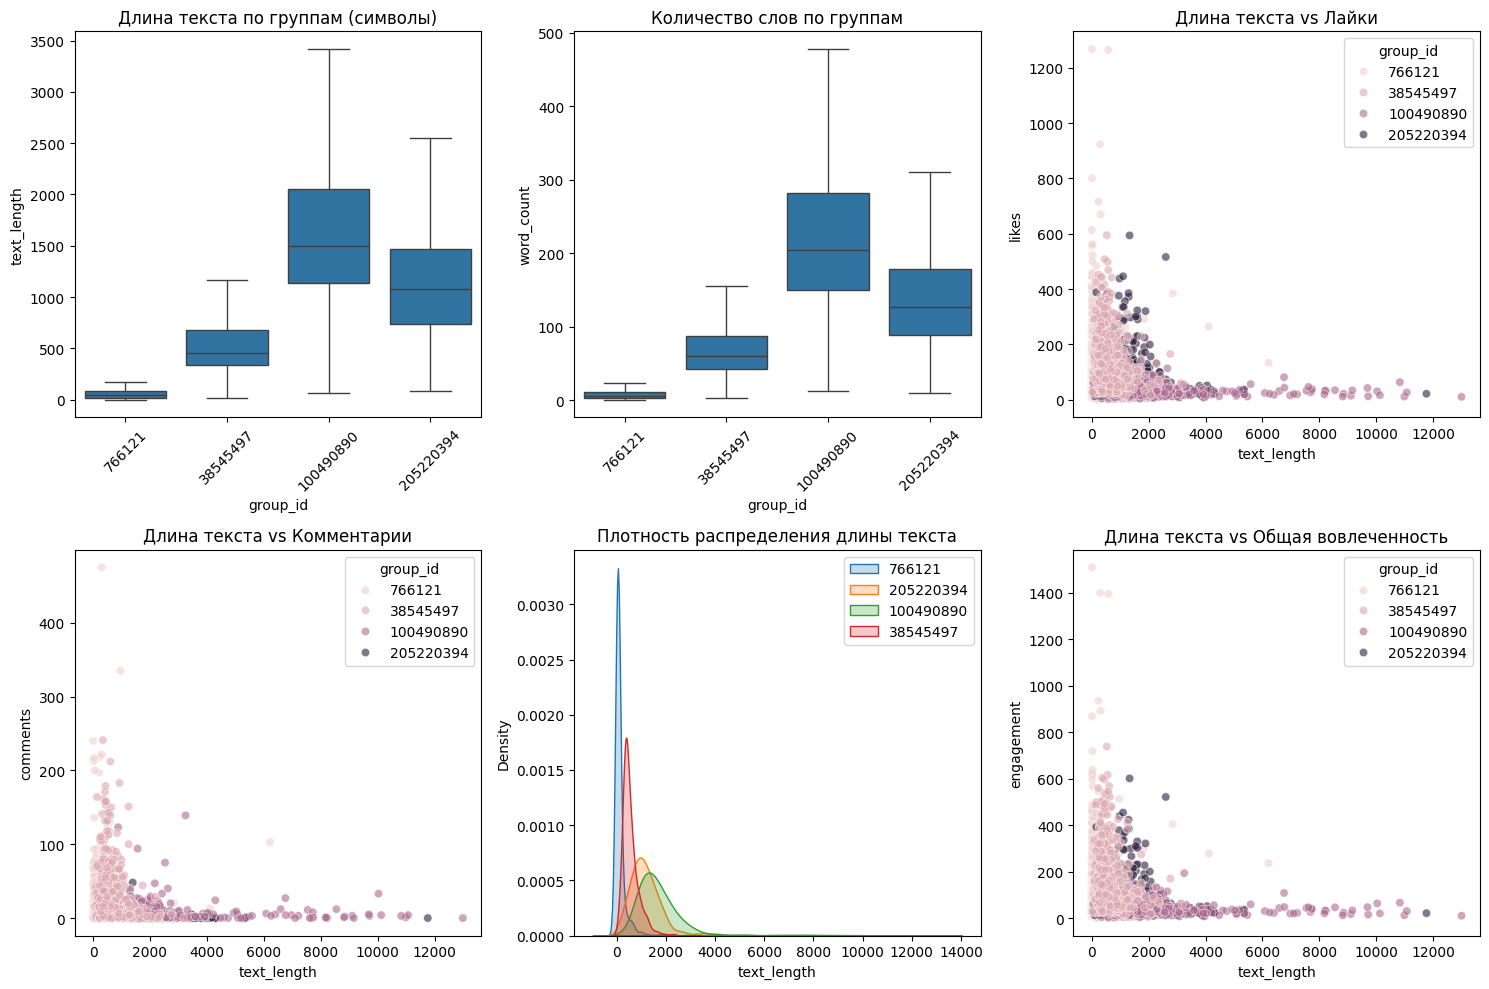

In [12]:
# 3.1 Анализ длины текстов
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='group_id', y='text_length', showfliers=False)
plt.title('Длина текста по группам (символы)')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='group_id', y='word_count', showfliers=False)
plt.title('Количество слов по группам')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
# Взаимосвязь длины текста и лайков
sns.scatterplot(data=df, x='text_length', y='likes', hue='group_id', alpha=0.6)
plt.title('Длина текста vs Лайки')

plt.subplot(2, 3, 4)
# Взаимосвязь длины текста и комментариев
sns.scatterplot(data=df, x='text_length', y='comments', hue='group_id', alpha=0.6)
plt.title('Длина текста vs Комментарии')

plt.subplot(2, 3, 5)
# Плотность распределения длины текста
for group in df['group_id'].unique():
    subset = df[df['group_id'] == group]
    sns.kdeplot(subset['text_length'], label=group, fill=True)
plt.title('Плотность распределения длины текста')
plt.legend()

plt.subplot(2, 3, 6)
# Соотношение длины текста и вовлеченности
df['engagement'] = df['likes'] + df['comments']
sns.scatterplot(data=df, x='text_length', y='engagement', hue='group_id', alpha=0.6)
plt.title('Длина текста vs Общая вовлеченность')

plt.tight_layout()
plt.show()